# Anomalie de corrélation N2/N3 <-> HWm_2/HWm_3 sur `toy_example5_scenario1`

**Contexte** : `reference/toy_example5_scenario1` (3 populations, `ta merge 1 3` puis `ts merge 1 2`, priors larges `N~UN[100,30000]`, `ta,ts~UN[10,30000]` avec contrainte `ts>ta` par rejet) montre un reftable complet (1000 particules) où `HWm_2` et `HWm_3` divergent fortement entre DIYABC et msprime (DIYABC~0.022, msprime~0.086) alors que `HWm_1` est correct.

**Le paradoxe** : une série de tests à paramètres FIXÉS (mêmes valeurs des deux côtés, moyennées sur 1000 répliques) montre que DIYABC et msprime tombent d'accord partout, y compris en reprenant les valeurs exactes tirées par DIYABC pour ses lignes les plus aberrantes. Un test contrôlé où seul N2 varie (N1=N3=15000, ta=5000, ts=15000 fixes) montre que **DIYABC sait très bien faire dépendre HWm_2 de N2** quand ta/ts sont fixés.

Pourtant, dans le reftable complet (où N1,N2,N3,ta,ts varient tous ensemble), la corrélation `HWm_2 <-> N2` observée côté DIYABC est quasi nulle (voire de signe opposé), alors que msprime montre la corrélation positive attendue par la théorie du coalescent. Seule la population 1 (celle qui **survit** aux deux fusions, jamais "dérivée") a un comportement DIYABC cohérent avec msprime.

Ce notebook documente cette anomalie de manière reproductible, avant d'aller regarder le code source C++ (`particuleC.cpp`, `history.cpp`) pour comprendre si c'est un vrai bug du binaire DIYABC de référence sur ce type de scénario (contrainte `ts>ta` par rejet sur intervalles de priors superposés), ou autre chose.

In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
print(f"ROOT_DIR : {ROOT_DIR}")
sys.path.insert(0, str(ROOT_DIR))

import glob  # noqa: E402
import subprocess  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402

from bridge.ancestry_simulation import (  # noqa: E402
    simulate_independent_loci,
    simulate_snp_genotypes,
)
from bridge.prior_parser import parse_priors  # noqa: E402
from bridge.reftable_loop import (  # noqa: E402
    run_reftable_simulation,
    write_reftable_txt,
)
from bridge.scenario_parser import parse_header_scenarios  # noqa: E402
from bridge.summary_statistics import compute_all_statistics  # noqa: E402

DIR_TE5 = ROOT_DIR / "reference" / "toy_example5_scenario1"
print(f"DIR_TE5 existe : {DIR_TE5.exists()}")

ROOT_DIR : /home/bernardr/Documents/Github/diyabc-msprime-poc


DIR_TE5 existe : True


/home/bernardr/miniconda3/envs/diyabc_msprime/lib/python3.11/site-packages/msprime/__init__.py:254: FutureWarning: 'msprime.TreeSequence' is deprecated and will be removed in future versions. Use 'tskit.TreeSequence'.
  warnings.warn(


## 1. Chargement des deux reftables complets (1000 particules, priors larges)

- `first_records_of_the_reference_table_0.txt` : sortie **réelle** du binaire DIYABC (vérité terrain, jamais modifiée).
- `reftable_msprime_fresh.txt` : régénérée ici via `run_reftable_simulation`, même `headerRF.txt`, même nombre de loci/particules, scenario 1 uniquement (pas de mélange de scénarios).

In [2]:
header_text = (DIR_TE5 / "headerRF.txt").read_text()
priors, constraints = parse_priors(header_text)
scenarios = parse_header_scenarios(header_text)
scenario1 = [s for s in scenarios if s.index == 1]
print("contraintes d'ordre :", constraints)

results = run_reftable_simulation(
    reference_directory=DIR_TE5,
    scenarios=scenario1,
    num_loci=100,
    nrec=1000,
    stats_filter="HEADER",
    max_workers=16,
)
write_reftable_txt(results, priors, scenario1, DIR_TE5 / "reftable_msprime_fresh.txt")
print("reftable msprime (scenario 1 uniquement) regenere.")

contraintes d'ordre : [OrderConstraint(param1='ts', operator='>', param2='ta')]


reftable msprime (scenario 1 uniquement) regenere.


In [3]:
df_diy = pd.read_csv(DIR_TE5 / "first_records_of_the_reference_table_0.txt", sep=r"\s+")
df_msp = pd.read_csv(DIR_TE5 / "reftable_msprime_fresh.txt", sep=r"\s+")

print(
    "DIYABC   :", df_diy.shape, "scenarios :", df_diy.scenario.value_counts().to_dict()
)
print(
    "msprime  :", df_msp.shape, "scenarios :", df_msp.scenario.value_counts().to_dict()
)
df_diy[["N1", "N2", "N3", "ta", "ts"]].describe()

DIYABC   : (1000, 58) scenarios : {1: 1000}
msprime  : (1000, 56) scenarios : {1: 1000}


,N1,N2,N3,ta,ts
count,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000
mean,15262.081000,15223.74700,14612.281000,10238.80800,20084.113000
std,8791.912851,8575.78838,8810.311543,7378.76611,7207.558352
min,194.000000,181.00000,109.000000,10.00000,577.000000
25%,7276.750000,7859.25000,6898.000000,3942.50000,14915.000000
50%,15596.000000,15415.50000,14634.000000,8719.00000,21262.500000
75%,22973.500000,22674.50000,22204.250000,15742.00000,26360.500000
max,29968.000000,29985.00000,29998.000000,29159.00000,29979.000000


## 2. Corrélation `HWm_i <-> N_i` (et `ta`, `ts`), par population

Théoriquement, l'hétérozygotie moyenne d'une population isolée doit crоître avec sa taille efficace propre (plus de temps de coalescence → plus de diversité retenue). C'est ce que montre msprime pour les 3 populations. DIYABC ne le montre que pour la population 1 (l'ancestrale qui survit aux deux fusions) -- pas pour 2 et 3 (les populations "dérivées", qui disparaissent chacune dans une fusion).

In [4]:
def correlation_table(df, label):
    rows = []
    for pop, N_col in [("1", "N1"), ("2", "N2"), ("3", "N3")]:
        hw = df[f"HWm_{pop}"]
        rows.append(
            {
                "simulateur": label,
                "pop": pop,
                "role": "ancestrale (survit)" if pop == "1" else "derivee (disparait)",
                "HWm_mean": hw.mean(),
                "HWm_std": hw.std(),
                f"corr(N{pop})": np.corrcoef(hw, df[N_col])[0, 1],
                "corr(ta)": np.corrcoef(hw, df.ta)[0, 1],
                "corr(ts)": np.corrcoef(hw, df.ts)[0, 1],
            }
        )
    return pd.DataFrame(rows)


corr_diy = correlation_table(df_diy, "DIYABC")
corr_msp = correlation_table(df_msp, "msprime")
corr_table = pd.concat([corr_diy, corr_msp], ignore_index=True)
corr_table

,simulateur,pop,role,HWm_mean,HWm_std,corr(N1),corr(ta),corr(ts),corr(N2),corr(N3)
0,DIYABC,1,ancestrale (survit),0.084159,0.037578,0.337697,-0.268616,-0.253234,NaN,NaN
1,DIYABC,2,derivee (disparait),0.022304,0.007882,NaN,-0.106503,-0.084476,-0.186838,NaN
2,DIYABC,3,derivee (disparait),0.020745,0.007648,NaN,-0.160167,-0.139961,NaN,-0.176885
3,msprime,1,ancestrale (survit),0.091203,0.043209,0.818370,-0.177439,-0.211481,NaN,NaN
4,msprime,2,derivee (disparait),0.085950,0.035771,NaN,-0.180285,-0.174968,0.704613,NaN
5,msprime,3,derivee (disparait),0.084743,0.036698,NaN,-0.182777,-0.175025,NaN,0.456654


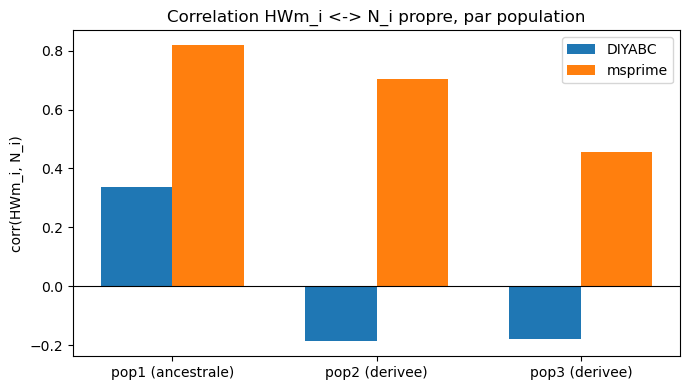

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3)
width = 0.35
corr_col_diy = [
    corr_diy.loc[corr_diy["pop"] == p, f"corr(N{p})"].iloc[0] for p in ["1", "2", "3"]
]
corr_col_msp = [
    corr_msp.loc[corr_msp["pop"] == p, f"corr(N{p})"].iloc[0] for p in ["1", "2", "3"]
]
ax.bar(x - width / 2, corr_col_diy, width, label="DIYABC")
ax.bar(x + width / 2, corr_col_msp, width, label="msprime")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(["pop1 (ancestrale)", "pop2 (derivee)", "pop3 (derivee)"])
ax.set_ylabel("corr(HWm_i, N_i)")
ax.set_title("Correlation HWm_i <-> N_i propre, par population")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Nuages de points `HWm_i` vs `N_i`

Visuellement : pop1 doit ressembler à un nuage croissant des deux côtés. Pop2/pop3 devraient aussi être croissants (comme msprime le montre) -- mais DIYABC y est quasi plat.

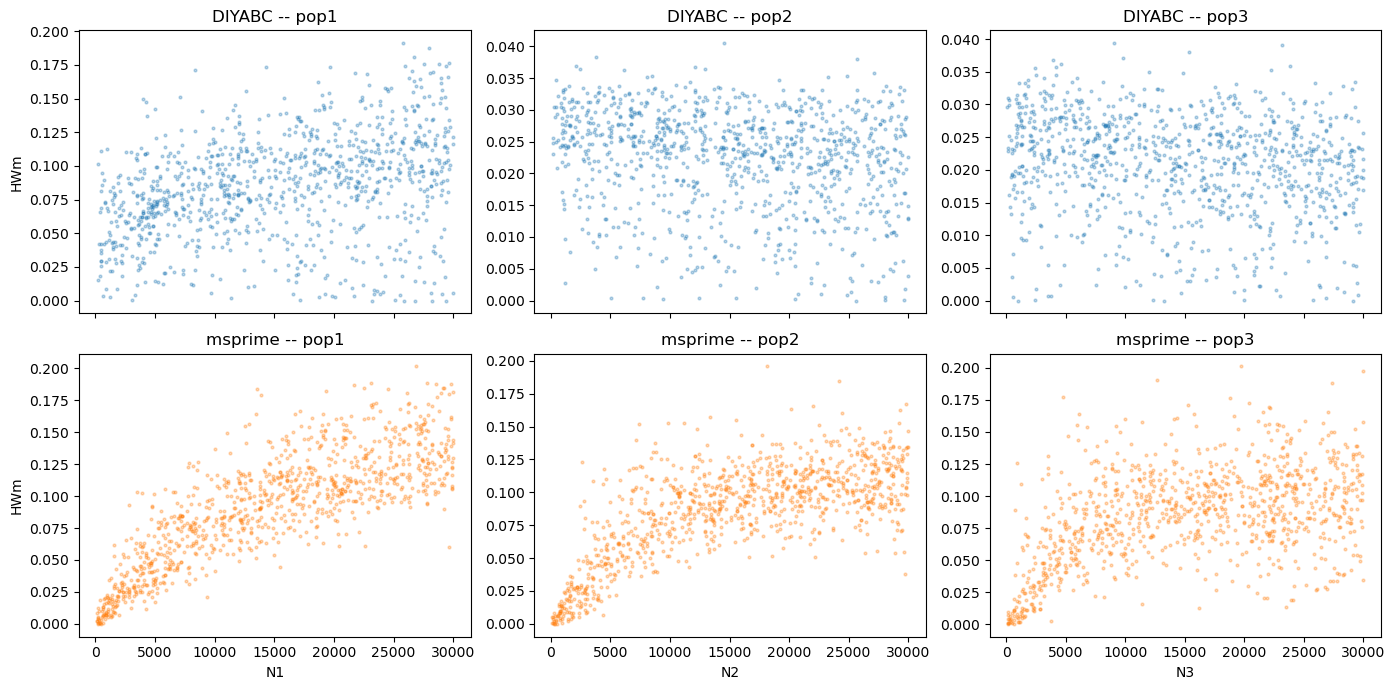

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex="col")
for col, (pop, N_col) in enumerate([("1", "N1"), ("2", "N2"), ("3", "N3")]):
    axes[0, col].scatter(
        df_diy[N_col], df_diy[f"HWm_{pop}"], s=4, alpha=0.3, color="C0"
    )
    axes[0, col].set_title(f"DIYABC -- pop{pop}")
    axes[1, col].scatter(
        df_msp[N_col], df_msp[f"HWm_{pop}"], s=4, alpha=0.3, color="C1"
    )
    axes[1, col].set_title(f"msprime -- pop{pop}")
    axes[1, col].set_xlabel(N_col)
for ax in axes[:, 0]:
    ax.set_ylabel("HWm")
plt.tight_layout()
plt.show()

## 4. Test contrôlé : ne faire varier QUE N2 (ta, ts, N1, N3 fixes)

Contrairement au reftable complet (où N1,N2,N3,ta,ts varient tous simultanement), ici on fixe tout sauf N2 (`N1=N3=15000`, `ta=5000`, `ts=15000`) et on simule 1000 repliques par valeur de N2 des deux cotes (option `-k` de DIYABC, valeurs figees, pas de tirage de prior -- meme technique que `compare_raw_genotypes_fixed_params.ipynb`).

Si DIYABC etait structurellement incapable de faire varier HWm_2 avec N2, ce test controle le montrerait aussi. On va voir que ce n'est PAS le cas : isolement, DIYABC scale tres correctement avec N2 -- le probleme n'apparait que lorsque N1,N2,N3,ta,ts varient tous ensemble.

In [7]:
def read_snp_dosages(path):
    """Lit un fichier .snp DIYABC -> {pop: [[dosage par locus] par individu]}."""
    lines = [line for line in Path(path).read_text().splitlines() if line.strip()]
    genos_by_pop = {}
    for line in lines[2:]:
        tokens = line.split()
        pop, genos = tokens[2], [int(x) for x in tokens[3:]]
        genos_by_pop.setdefault(pop, []).append(genos)
    return genos_by_pop


def dosages_to_genotypes_per_locus(genos_by_pop):
    pop_names = list(genos_by_pop.keys())
    n_loci = len(next(iter(genos_by_pop.values()))[0])
    genotypes_per_locus = []
    for loc in range(n_loci):
        locus_dict = {}
        for pop in pop_names:
            haploids = []
            for dosage_row in genos_by_pop[pop]:
                d = dosage_row[loc]
                haploids += {0: [0, 0], 1: [0, 1], 2: [1, 1]}[d]
            locus_dict[pop] = haploids
        genotypes_per_locus.append(locus_dict)
    return genotypes_per_locus, pop_names


def run_diyabc_fixed(
    general_binary, dir_ref, n1, n2, n3, ta, ts, n_replicates=1000, n_loci=100
):
    dir_ref.mkdir(parents=True, exist_ok=True)
    headersim_content = f"""simu_test {n_replicates}
3
20 0
20 0
20 0

scenario 6
N1 N2 N3
0 sample 1
0 sample 2
0 sample 3
ta merge 1 3
ts merge 1 2

historical parameters (5)
N1 N {n1}
N2 N {n2}
N3 N {n3}
ta T {ta}
ts T {ts}

loci description ({n_loci})
{n_loci} <A> [P] *1
"""
    (dir_ref / "headersim.txt").write_text(headersim_content)
    for f in glob.glob(str(dir_ref / "simu_test_*.snp")):
        Path(f).unlink()
    rng_state = dir_ref / "RNG_state_0000.bin"
    if rng_state.exists():
        rng_state.unlink()
    subprocess.run(
        [str(general_binary), "-p", "./", "-n", "-t", "8"],
        cwd=dir_ref,
        check=True,
        capture_output=True,
        text=True,
    )
    subprocess.run(
        [str(general_binary), "-p", "./", "-k", "-s", "123", "-t", "8"],
        cwd=dir_ref,
        check=True,
        capture_output=True,
        text=True,
    )
    files = sorted(
        glob.glob(str(dir_ref / "simu_test_*.snp")),
        key=lambda p: int(Path(p).stem.rsplit("_", 1)[1]),
    )
    rows = []
    for f in files:
        genos_by_pop = read_snp_dosages(f)
        gpl, pop_names = dosages_to_genotypes_per_locus(genos_by_pop)
        rows.append(compute_all_statistics(gpl, pop_names))
    return pd.DataFrame(rows)


def run_msprime_fixed(n1, n2, n3, ta, ts, n_replicates=1000, n_loci=100):
    import msprime

    demography = msprime.Demography()
    demography.add_population(name="pop1", initial_size=n1, initially_active=True)
    demography.add_population(name="pop2", initial_size=n2, initially_active=True)
    demography.add_population(name="pop3", initial_size=n3, initially_active=True)
    demography.add_population_split(time=ta, derived=["pop3"], ancestral="pop1")
    demography.add_population_split(time=ts, derived=["pop2"], ancestral="pop1")
    demography.sort_events()

    rows = []
    for seed in range(1, n_replicates + 1):
        ts_iter = simulate_independent_loci(
            demography=demography,
            samples={"pop1": 20, "pop2": 20, "pop3": 20},
            num_loci=n_loci,
            seed=seed,
        )
        gpl = list(simulate_snp_genotypes(ts_iter, seed=seed))
        rows.append(compute_all_statistics(gpl, ["pop1", "pop2", "pop3"]))
    return pd.DataFrame(rows)

In [8]:
GENERAL_BINARY = DIR_TE5 / "diyabc"
N2_VALUES = [500, 5000, 25000]
FIXED_N1_N3, FIXED_TA, FIXED_TS = 15000, 5000, 15000

sweep_rows = []
for n2 in N2_VALUES:
    dir_ref = ROOT_DIR / "reference" / f"toy_vary_n2_{n2}_nb"
    df_diy_fixed = run_diyabc_fixed(
        GENERAL_BINARY, dir_ref, FIXED_N1_N3, n2, FIXED_N1_N3, FIXED_TA, FIXED_TS
    )
    df_msp_fixed = run_msprime_fixed(FIXED_N1_N3, n2, FIXED_N1_N3, FIXED_TA, FIXED_TS)
    sweep_rows.append(
        {
            "N2": n2,
            "HWm_2_diyabc": df_diy_fixed["HWm_2"].mean(),
            "HWm_2_msprime": df_msp_fixed["HWm_2"].mean(),
        }
    )
    print(
        f"N2={n2}: DIYABC HWm_2={sweep_rows[-1]['HWm_2_diyabc']:.4f}  msprime HWm_2={sweep_rows[-1]['HWm_2_msprime']:.4f}"
    )

df_sweep = pd.DataFrame(sweep_rows)
df_sweep

N2=500: DIYABC HWm_2=0.0049  msprime HWm_2=0.0051


N2=5000: DIYABC HWm_2=0.0581  msprime HWm_2=0.0586


N2=25000: DIYABC HWm_2=0.1083  msprime HWm_2=0.1077


,N2,HWm_2_diyabc,HWm_2_msprime
0,500,0.004861,0.005134
1,5000,0.058113,0.058552
2,25000,0.108329,0.107668


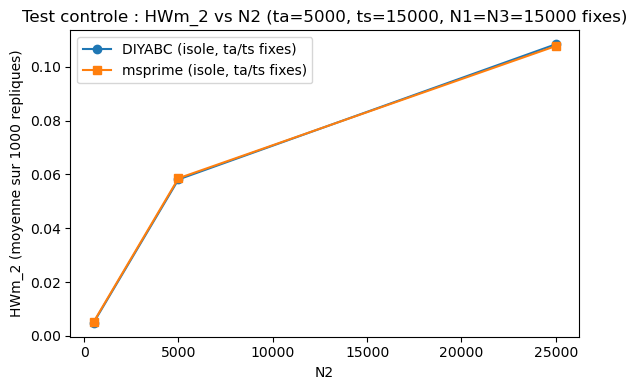

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df_sweep.N2, df_sweep.HWm_2_diyabc, "o-", label="DIYABC (isole, ta/ts fixes)")
ax.plot(df_sweep.N2, df_sweep.HWm_2_msprime, "s-", label="msprime (isole, ta/ts fixes)")
ax.set_xlabel("N2")
ax.set_ylabel("HWm_2 (moyenne sur 1000 repliques)")
ax.set_title("Test controle : HWm_2 vs N2 (ta=5000, ts=15000, N1=N3=15000 fixes)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Conclusion : le paradoxe

- **Isole** (section 4) : DIYABC fait varier `HWm_2` avec `N2` exactement comme msprime -- la formule/le moteur de coalescence de DIYABC scale correctement avec la taille de population d'une population "derivee".
- **Dans le reftable complet** (section 2-3), avec N1,N2,N3,ta,ts tires simultanement dans des priors larges (`N~UN[100,30000]`, `ta,ts~UN[10,30000]` avec `ts>ta` par rejet), cette dependance **disparait** cote DIYABC specifiquement pour les populations 2 et 3 (celles qui *disparaissent* dans une fusion), alors qu'elle reste correcte et forte cote msprime, et que la population 1 (celle qui *survit* aux deux fusions) reste correcte des deux cotes.

Cette asymetrie -- correcte en isolement, cassee uniquement pour les populations "derivees" quand tous les parametres varient ensemble -- pointe vers quelque chose de specifique au mecanisme de tirage/simulation reel de DIYABC pour ce type de scenario (contrainte d'ordre `ts>ta` par rejet sur des intervalles de prior superposes), plutot que vers une erreur dans notre port msprime (deja verifie exhaustivement point par point). Prochaine etape : lecture du code source C++ (`particuleC.cpp`, `history.cpp`) pour voir comment DIYABC gere le tirage/l'application des parametres `N2`/`N3`/`ta`/`ts` pour les populations "derivees" d'une fusion, en particulier sous contrainte `DRAW UNTIL`.